In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Harmonic Oscillator Recurrent Network (HORN)

**HORN** is a recurrent network of damped, driven harmonic oscillators used as a trainable dynamical reservoir / sequence model. Each unit is a second-order oscillator with position $x$ and velocity $y$,

$$\ddot x + \gamma\,\dot x + \omega^2 x = \alpha\,\phi(\text{input} + \text{recurrent}),$$

so the network embeds inputs into a bank of coupled resonators. Stacked as `HORNSeqLayer` / `HORNSeqNetwork`, it can be trained on sequence tasks (see the *Training on tasks* tutorial). Here we drive a single `HORNStep` layer and watch its oscillatory hidden state.

**Reference:** Effenberger, Carvalho, Jain et al. (2025), *A biology-inspired recurrent oscillator network for computations in high-dimensional state space* (HORN), bioRxiv.

## Build the model

A single HORN layer with `in_size = 16` oscillatory units. We raise `alpha` to make the response visibly oscillatory.

In [2]:
node = brainmass.HORNStep(in_size=16, alpha=0.3)
node

HORNStep(
  in_size=(16,),
  out_size=(16,),
  alpha=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.3, dtype=float32)
  ),
  omega=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.22439948, dtype=float32)
  ),
  gamma=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.01, dtype=float32)
  ),
  v=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  x_init=Constant(value=0.0),
  y_init=Constant(value=0.0)
)

## Run a simulation

We drive the layer with a brief input pulse and let it ring down — a sequence model's impulse response. `HORNStep.update(inputs)` takes one positional input, so we provide it via the `Simulator`'s `inputs` callable.

In [3]:
def pulse(i, t):
    on = (t >= 5. * u.ms) & (t < 8. * u.ms)
    return jnp.where(on, 1.0, 0.0) * jnp.ones((16,))

sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(120. * u.ms, inputs=pulse, monitors=['x', 'y'])
res['x'].shape

(1200, 16)

## Visualize

Left: the position state of a few units ringing after the pulse. Right: a position-velocity phase portrait of one unit spiraling toward rest.

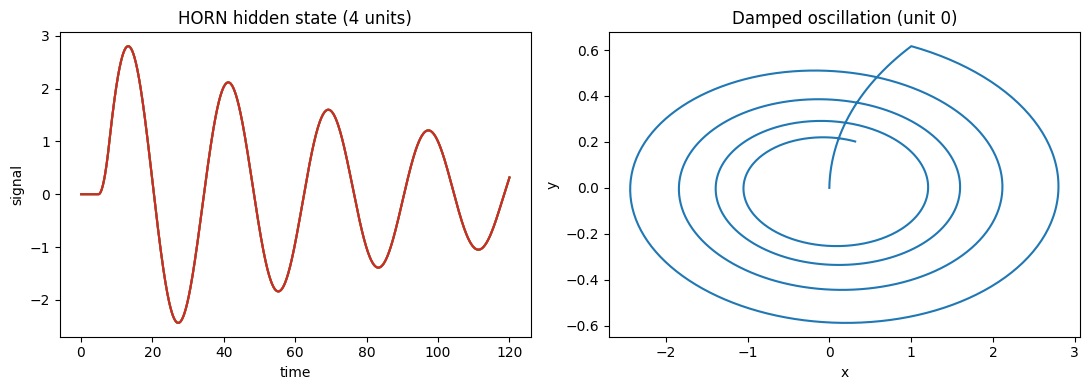

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
brainmass.viz.plot_timeseries(res['x'][:, :4], ts=res['ts'], ax=axes[0])
axes[0].set_title('HORN hidden state (4 units)')
brainmass.viz.plot_phase_portrait(res['x'][:, 0], res['y'][:, 0], ax=axes[1])
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Damped oscillation (unit 0)')
plt.tight_layout()
plt.show()

## Try it: vary the damping `gamma`

More damping makes the impulse response decay faster (shorter memory); less damping lets the oscillators ring longer. The sequence-model variants `HORNSeqLayer` and `HORNSeqNetwork` stack these units and add trainable input/recurrent/output weights — see {doc}`/tutorials/08_training_on_tasks`.

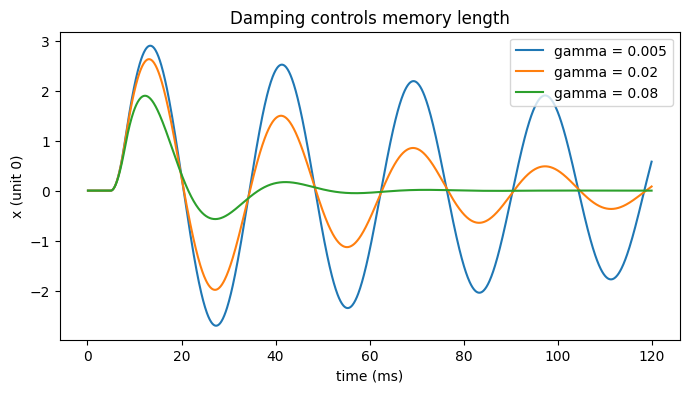

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for gamma in [0.005, 0.02, 0.08]:
    m = brainmass.HORNStep(in_size=16, alpha=0.3, gamma=gamma)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(120. * u.ms, inputs=pulse,
                                                  monitors=['x'])
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['x'])[:, 0],
            label=f'gamma = {gamma}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('x (unit 0)'); ax.legend()
ax.set_title('Damping controls memory length')
plt.show()